## Derivative-Constrained PINN — Gibson–Schwartz convenience-yield inversion

Self-contained: the closed-form GS pricer is copied in below (not imported from `gs_wamol`), with an autodiff PDE self-check.

Architecture:
- **Path net** `delta_hat_phi(t)` — latent convenience yield.
- **Drift net** `A_hat_theta(tau)` — `B(tau)` is analytic (closed form); only `A(tau)` is learned.
- **Pricing transform**: `F_hat = S * exp(B(tau) * delta_hat + A_hat)`.
- **Loss** = `e_data` (price MSE) + `e_ode` (ODE residual on `A_hat`) + `e_sde` (OU transition NLL on the path), WamOL-balanced.

In [1]:
import os
import sys
import types
import pickle
import time
from dataclasses import dataclass, asdict
from typing import Callable, Dict, Tuple, Union

import jax
import jax.numpy as jnp
from jax import grad, jacrev, jit, lax, random, vmap
from jax.nn.initializers import glorot_normal, normal, zeros
from jax.flatten_util import ravel_pytree
from jax.tree_util import tree_leaves, tree_map

import optax
import ml_collections
from flax import linen as nn
from flax.training import train_state, orbax_utils
import orbax.checkpoint

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
print("JAX:", jax.__version__, "| x64 enabled:", jax.config.jax_enable_x64,
      "| default dtype:", jnp.ones(1).dtype)


JAX: 0.9.1 | x64 enabled: False | default dtype: float32


### Closed-form Gibson–Schwartz pricer

$$\hat{F}(\tau, S, \delta) = S\exp\!\big[B(\tau)\delta + A(\tau)\big],\qquad B(\tau) = -\frac{1-e^{-\kappa\tau}}{\kappa}$$

`B_coeff` is used directly in the pricing transform below. `A_coeff`/`futures`/`GSParams` are not used in the loss (that would trivially satisfy the PDE) — they only back the self-check at the bottom of this cell.

In [2]:
# Gibson-Schwartz Model 2 closed-form futures pricer. Do not edit these
# coefficients without re-running the self-check below.


@dataclass(frozen=True)
class GSParams:
    """Risk-neutral GS Model 2 params. alpha_Q = alpha_P - sigma2*lambda2/kappa."""
    r: float
    kappa: float
    alpha_Q: float
    sigma1: float
    sigma2: float
    rho: float


def B_coeff(tau, kappa):
    return -(1.0 - jnp.exp(-kappa * tau)) / kappa


def A_coeff(tau, p: GSParams):
    kappa = p.kappa
    s1s2rho = p.sigma1 * p.sigma2 * p.rho
    s2sq = p.sigma2 ** 2

    lin = (p.r - p.alpha_Q + 0.5 * s2sq / kappa ** 2 - s1s2rho / kappa) * tau
    two_kappa = 0.25 * s2sq * (1.0 - jnp.exp(-2.0 * kappa * tau)) / kappa ** 3
    one_kappa = (p.alpha_Q * kappa + s1s2rho - s2sq / kappa) * (1.0 - jnp.exp(-kappa * tau)) / kappa ** 2
    return lin + two_kappa + one_kappa


def log_futures(tau, S, delta, p: GSParams):
    return jnp.log(S) + B_coeff(tau, p.kappa) * delta + A_coeff(tau, p)


def futures(tau, S, delta, p: GSParams):
    return jnp.exp(log_futures(tau, S, delta, p))


# Pickle resolution shim: mc_data.pkl stores GSParams by class path, so
# resolve it to the class defined above instead of the gs_wamol package.
_gs_shim = types.ModuleType("gs_wamol.physics.gibson_schwartz")
_gs_shim.GSParams = GSParams
sys.modules.setdefault("gs_wamol", types.ModuleType("gs_wamol"))
sys.modules.setdefault("gs_wamol.physics", types.ModuleType("gs_wamol.physics"))
sys.modules["gs_wamol.physics.gibson_schwartz"] = _gs_shim


def _gs_selfcheck():
    """Autodiff check that the ported closed form still solves the pricing PDE."""
    p = GSParams(r=0.05, kappa=1.876, alpha_Q=0.0779, sigma1=0.393, sigma2=0.527, rho=0.766)

    def F(tau, S, delta):
        return futures(tau, S, delta, p)

    def residual(tau, S, delta):
        F_tau = grad(F, 0)(tau, S, delta)
        F_S = grad(F, 1)(tau, S, delta)
        F_SS = grad(grad(F, 1), 1)(tau, S, delta)
        F_d = grad(F, 2)(tau, S, delta)
        F_dd = grad(grad(F, 2), 2)(tau, S, delta)
        F_Sd = grad(grad(F, 1), 2)(tau, S, delta)
        return (F_tau
                - (p.r - delta) * S * F_S
                - p.kappa * (p.alpha_Q - delta) * F_d
                - 0.5 * p.sigma1 ** 2 * S ** 2 * F_SS
                - p.rho * p.sigma1 * p.sigma2 * S * F_Sd
                - 0.5 * p.sigma2 ** 2 * F_dd)

    k1, k2, k3 = random.split(random.PRNGKey(0), 3)
    tau = random.uniform(k1, (256,), minval=0.05, maxval=2.0)
    S = random.uniform(k2, (256,), minval=30.0, maxval=170.0)
    d = random.uniform(k3, (256,), minval=-1.0, maxval=1.5)

    rel_pde = jnp.max(jnp.abs(vmap(residual)(tau, S, d) / vmap(F)(tau, S, d)))
    rel_ic = jnp.max(jnp.abs(vmap(lambda S_, d_: F(0.0, S_, d_))(S, d) / S - 1.0))

    tol = 1e-4 if jnp.ones(1).dtype == jnp.float32 else 1e-10
    assert rel_pde < tol, f"ported A/B break the GS PDE: rel residual {rel_pde:.3e}"
    assert rel_ic < tol, f"ported A/B break F(0,S,delta)=S: rel error {rel_ic:.3e}"
    print(f"GS pricer self-check OK  |  rel PDE residual {rel_pde:.2e}, rel IC error {rel_ic:.2e}")


_gs_selfcheck()

GS pricer self-check OK  |  rel PDE residual 2.76e-07, rel IC error 2.98e-07


### Network architecture

Generic `MLP` with optional weight-factorization reparameterisation on `Dense`. Two instances are built below: the drift net `A_hat_theta(tau)` and the path net `delta_hat_phi(t)`.

In [3]:
activation_fn = {
    "tanh": jnp.tanh,
    "sin": jnp.sin,
}


def _get_activation(name):
    if name in activation_fn:
        return activation_fn[name]
    raise NotImplementedError(f"Activation {name} not in dictionary: {activation_fn.keys()}")


def _weight_fact(init_fn, mean, stddev):
    def init(key, shape):
        key1, key2 = random.split(key)
        w = init_fn(key1, shape)
        g = mean + normal(stddev)(key2, (shape[-1],))
        g = jnp.exp(g)
        v = w / g
        return g, v
    return init


class Dense(nn.Module):
    features: int
    kernel_init: Callable = glorot_normal()
    bias_init: Callable = zeros
    reparam: Union[None, Dict] = None

    @nn.compact
    def __call__(self, x):
        if self.reparam is None:
            kernel = self.param(
                "kernel", self.kernel_init, (x.shape[-1], self.features)
            )
        elif self.reparam["type"] == "weight_fact":
            g, v = self.param(
                "kernel",
                _weight_fact(
                    self.kernel_init,
                    mean=self.reparam["mean"],
                    stddev=self.reparam["stddev"],
                ),
                (x.shape[-1], self.features),
            )
            kernel = g * v
        bias = self.param("bias", self.bias_init, (self.features,))
        y = jnp.dot(x, kernel) + bias
        return y


class MLP(nn.Module):
    hidden_dim: Tuple[int] = (32, 16)
    out_dim: int = 1
    activation: str = "tanh"
    reparam: Union[None, Dict] = None

    def setup(self):
        self.activation_fn = _get_activation(self.activation)

    @nn.compact
    def __call__(self, x):
        for i in range(len(self.hidden_dim)):
            x = Dense(features=self.hidden_dim[i], reparam=self.reparam)(x)
            x = self.activation_fn(x)
        x = Dense(features=self.out_dim, reparam=self.reparam)(x)
        return x

### Build Networks

* Path net: `delta_hat_phi(t)` — latent convenience yield.
* Drift net: `A_hat_theta(tau)` — `B(tau)` is analytic (closed form); only `A(tau)` is learned.
* Pricing transform: `F_hat = S * exp(B(tau) * delta_hat + A_hat)`.
* Loss = `e_data` (price MSE) + `e_ode` (ODE residual on `A_hat`) + `e_sde` (OU transition NLL on the path), WamOL-balanced.

```mermaid
flowchart LR
    tau --> normalize_tau --> drift_ann --> A_hat["A_hat(tau) = tau * N_theta(tau)"]
    t --> normalize_time --> path_ann --> delta_hat["delta_hat_phi(t)"]
    A_hat --> logF["log F_hat = log(S) + B(tau)*delta + A_hat(tau)"]
    delta_hat --> logF
    S --> logF
```


In [4]:
def build_nets(config):
    reparam = None
    if config.ann_reparam:
        reparam = ml_collections.ConfigDict({"type": "weight_fact", "mean": 0.5, "stddev": 0.1})

    # drift_ann takes tau alone (in_dim 1), not (S, delta, tau) (in_dim 3).
    drift_ann = MLP(hidden_dim=config.drift_hidden_dim,
                    out_dim=1,
                    activation=config.ann_activation_str,
                    reparam=reparam)
    path_ann = MLP(hidden_dim=config.path_hidden_dim,
                   out_dim=1,
                   activation=config.ann_activation_str,
                   reparam=reparam)
    return drift_ann, path_ann


# ------------------------------------------------------------------
# Learnable GS parameters  psi = {kappa, sigma1, sigma2, rho, alpha_Q, alpha_P}.
# r is held fixed (observable risk-free rate). kappa and sigma2 are
# measure-invariant, so a SINGLE kappa/sigma2 serves both the Q pricing side
# (p_Q, via B(tau) and the ODE RHS) and the P transition side (e_sde); only
# alpha differs across measures (alpha_Q vs alpha_P). Constraints are imposed by
# reparameterisation so the optimiser works in unconstrained space:
#   kappa, sigma1, sigma2 = softplus(raw)  (> 0)
#   rho                   = tanh(raw)      (in (-1, 1))
#   alpha_Q, alpha_P      = raw            (unconstrained)
# ------------------------------------------------------------------
R_FIXED = 0.05


def constrain_psi(raw):
    return {
        "kappa":   jax.nn.softplus(raw["kappa"]),
        "sigma1":  jax.nn.softplus(raw["sigma1"]),
        "sigma2":  jax.nn.softplus(raw["sigma2"]),
        "rho":     jnp.tanh(raw["rho"]),
        "alpha_Q": raw["alpha_Q"],
        "alpha_P": raw["alpha_P"],
    }


def _softplus_inv(y):
    # invert softplus so a desired positive start value maps to its raw pre-image
    return float(np.log(np.expm1(y)))


def raw_psi_init(psi0):
    # psi0: dict of desired *constrained* start values -> raw (unconstrained) leaf
    return {
        "kappa":   jnp.asarray(_softplus_inv(psi0["kappa"])),
        "sigma1":  jnp.asarray(_softplus_inv(psi0["sigma1"])),
        "sigma2":  jnp.asarray(_softplus_inv(psi0["sigma2"])),
        "rho":     jnp.asarray(float(np.arctanh(psi0["rho"]))),
        "alpha_Q": jnp.asarray(psi0["alpha_Q"]),
        "alpha_P": jnp.asarray(psi0["alpha_P"]),
    }


def psi_to_gsparams(psi):
    # Effective Q pricing params + the P transition triple, all from learned psi.
    p_Q_eff = GSParams(r=R_FIXED, kappa=psi["kappa"], alpha_Q=psi["alpha_Q"],
                       sigma1=psi["sigma1"], sigma2=psi["sigma2"], rho=psi["rho"])
    return {"p_Q": p_Q_eff, "kappa_P": psi["kappa"],
            "alpha_P": psi["alpha_P"], "sigma2_P": psi["sigma2"]}


def make_fns(drift_ann, path_ann, params):
    # psi is now a learned leaf of `params`; build the effective GS params from it
    # rather than closing over the (true) globals. gsp is returned as a 4th element
    # so error()/plots price and score with the *learned* parameters.
    psi = constrain_psi(params["psi"])
    gsp = psi_to_gsparams(psi)
    p_Q_eff = gsp["p_Q"]

    # boundary condition A(0)=0 -> tau * N(0) = 0 regardless of N's output (hard)
    def A_hat_fn(tau):
        return tau * drift_ann.apply(params["drift"], normalize_tau(tau))[0]

    # pricing transform: spot, analytic B(tau; learned kappa), state delta, learned A(tau)
    def log_F_hat_fn(S, delta, tau):
        return jnp.log(S) + B_coeff(tau, p_Q_eff.kappa) * delta + A_hat_fn(tau)

    def F_hat_fn(S, delta, tau):
        return jnp.exp(log_F_hat_fn(S, delta, tau))

    def delta_hat_fn(t):
        return path_ann.apply(params["path"], normalize_time(t))[0]

    return F_hat_fn, delta_hat_fn, A_hat_fn, gsp


# one param dict so optax/Flax jointly train the drift net, path net AND psi.
def init_nets(config, key):
    drift_ann, path_ann = build_nets(config)
    k_s, k_p = random.split(key, 2)
    params = {
        "drift": drift_ann.init(k_s, jnp.ones((1,))),
        "path": path_ann.init(k_p, jnp.ones((1,))),
        "psi": raw_psi_init(PSI_INIT),   # perturbed-from-truth init (see data cell)
    }
    return drift_ann, path_ann, params

### Optimiser

Core code inherited from https://github.com/khoshisashi/AC-PINNs/blob/main/AC_PINNs_IVS_calibration.ipynb for the original SABR / Dupire-local-vol problem by Khoshisashi et al. 2023. in his ACPINN repo.

In [5]:
import json

with open("../config/hp.sweep.json", "r") as f:
    adam_hp = json.load(f)

# build adam optimiser
# step size shrinks over training -> big steps initially -> reduce steps once oscillating around minima to settle precisely
def make_optimizer(hp):
    # learning rate schedule
    lr = optax.exponential_decay(
        init_value=hp["learning_rate"], 
        transition_steps=hp["decay_steps"],
        decay_rate=hp["decay_rate"],
    )
    return optax.adam(
        learning_rate=lr, b1=hp["beta1"], b2=hp["beta2"], eps=hp["adam_eps"]
    )

### Input Data

Monte Carlo simulated data generated by `monte_carlo.ipynb` and saved to `data/gs_mc_data.npz`.

Input data is a 2D array of `(t, S)` pairs, and the corresponding observed forward prices `F_obs` at those points. The network will learn to predict the convenience yield `delta_hat(t, S)` that best fits the observed forward prices under the Gibson-Schwartz model.

In [6]:
_MC_DATA_PATH = "../data/input/synthetic/mc_data.pkl"
_WTI_DATA_PATH = "../data/input/synthetic/wti_analysis_ready.csv"

def get_data(path_id=0, path="../data/input/synthetic/mc_data.pkl"):

    with open(path, "rb") as f:
        mc_data = pickle.load(f)

    taus = mc_data["taus"]                             
    t_train = mc_data["t_grid"]                          
    S_train = mc_data["S"][path_id]                      
    log_F_obs_train = mc_data["log_F_obs"][path_id]

    delta_true = mc_data["delta_true"][path_id] # eval target           

    p_Q = GSParams(**asdict(mc_data["params_Q"]))
    kappa_P = mc_data["params_P"]["kappa"]                 
    alpha_P = mc_data["params_P"]["alpha_P"]               
    sigma2_P = mc_data["params_P"]["sigma2"]               

    return t_train, S_train, taus, log_F_obs_train, delta_true, p_Q, kappa_P, alpha_P, sigma2_P


In [7]:
(t_train, S_train, taus, log_F_obs_train,
 delta_true, p_Q, kappa_P, alpha_P, sigma2_P) = get_data(path_id=0)

# pack into data tuple - excluding convenience yield
data = (t_train, S_train, log_F_obs_train)


T_SCALE = float(t_train[-1])
TAU_SCALE = float(taus.max())


def normalize_tau(tau):
    return jnp.atleast_1d(tau / TAU_SCALE) # ensure output shape 1-D


def normalize_time(t):
    return jnp.atleast_1d(t / T_SCALE)


# --- True psi: EVAL/PLOTS ONLY. Now that psi is a learned leaf of `params`,
# these true values are never fed to the model -- they only seed the perturbed
# init and provide the truth line in the recovery plots/table. ---
PSI_TRUE = {
    "kappa":   float(p_Q.kappa),
    "sigma1":  float(p_Q.sigma1),
    "sigma2":  float(p_Q.sigma2),
    "rho":     float(p_Q.rho),
    "alpha_Q": float(p_Q.alpha_Q),
    "alpha_P": float(alpha_P),
}
# Perturbed start (~30-50% off, mixed directions) -> recovery test, not stability.
PSI_INIT = {
    "kappa":   PSI_TRUE["kappa"]  * 1.5,
    "sigma1":  PSI_TRUE["sigma1"] * 0.7,
    "sigma2":  PSI_TRUE["sigma2"] * 1.3,
    "rho":     PSI_TRUE["rho"]    * 0.6,
    "alpha_Q": PSI_TRUE["alpha_Q"] + 0.06,
    "alpha_P": PSI_TRUE["alpha_P"] - 0.06,
}


# collocation mesh to evaluate physics residuals at -> random tau values spread across the mesh [0, tau_max] -> sampled from
N_COLLOCATION = 4096

_key_mesh = random.PRNGKey(0) # evaluates at diff points each run
tau_mesh = random.uniform(_key_mesh, (N_COLLOCATION,), minval=0.0, maxval=float(taus.max()))
mesh = tau_mesh

print("t_train        ", t_train.shape, f"[{float(t_train.min()):.2f}, {float(t_train.max()):.2f}]")
print("S_train        ", S_train.shape, f"[{float(S_train.min()):.2f}, {float(S_train.max()):.2f}]")
print("taus           ", taus.shape, f"[{float(taus.min()):.3f}, {float(taus.max()):.3f}]")
print("log_F_obs_train", log_F_obs_train.shape, "(dates x maturities)")
print("delta_true     ", delta_true.shape, "HELD OUT -- evaluation only")
print("collocation    ", tau_mesh.shape, "points over tau")
print("PSI_TRUE       ", {k: round(v, 4) for k, v in PSI_TRUE.items()})
print("PSI_INIT       ", {k: round(v, 4) for k, v in PSI_INIT.items()}, "(learned from here)")

t_train         (1001,) [0.00, 10.00]
S_train         (1001,) [35.89, 165.12]
taus            (12,) [0.083, 1.000]
log_F_obs_train (1001, 12) (dates x maturities)
delta_true      (1001,) HELD OUT -- evaluation only
collocation     (4096,) points over tau
PSI_TRUE        {'kappa': 1.876, 'sigma1': 0.393, 'sigma2': 0.527, 'rho': 0.766, 'alpha_Q': 0.0779, 'alpha_P': 0.106}
PSI_INIT        {'kappa': 2.814, 'sigma1': 0.2751, 'sigma2': 0.6851, 'rho': 0.4596, 'alpha_Q': 0.1379, 'alpha_P': 0.046} (learned from here)


### Loss terms — `error()`

Rewritten to match the attached architecture diagram (drift net + analytic B(tau) + three WamOL-balanced loss channels), replacing the earlier terms from `docs/mathematical_derivations-5.pdf`.

- `e_data` = the diagram's $\hat{\mathcal{L}}_{\text{data}}$ — data misfit in log-price space (was `e_acc`)
- `e_ode` = the diagram's $\hat{\mathcal{L}}_{\text{ODE}}$ — ODE residual on $\hat{A}(\tau)$ (replaces the old 3-D PDE residual `e_pde`)
- `e_sde` = the diagram's $\hat{\mathcal{L}}_{\text{SDE}}$ — OU transition-density residual on the recovered path (new)
- The old inequality terms (`e_arb_cac`, `e_arb_rcac`, `e_delta_floor`) and $\mathcal{L}_b$ are **removed** — not part of this architecture

In [8]:
def error(fns, data, mesh):
    F_hat_fn, delta_hat_fn, A_hat_fn, gsp = fns
    # psi is learned: pull the effective Q pricing params and the P transition
    # triple from gsp instead of the (true) globals. kappa_P/sigma2_P alias the
    # single learned kappa/sigma2 (measure-invariant); alpha_P is its own leaf.
    p_Q = gsp["p_Q"]
    kappa_P = gsp["kappa_P"]
    alpha_P = gsp["alpha_P"]
    sigma2_P = gsp["sigma2_P"]
    t_train, S_train, log_F_obs_train = data
    tau_mesh = mesh

    # Latent path at observation times. Input is t alone (S6 remark 1).
    delta_hat = vmap(delta_hat_fn)(t_train)                          # (n,)

    def log_F_hat_fn(S, delta, tau):
        return jnp.log(S) + B_coeff(tau, p_Q.kappa) * delta + A_hat_fn(tau)

    log_F_hat = vmap(
        lambda S, d: vmap(lambda tau: log_F_hat_fn(S, d, tau))(taus)
    )(S_train, delta_hat)                                            # (n, K)
    e_data = (log_F_hat - log_F_obs_train) ** 2                       # (n, K)

    def ode_residual(tau):
        A_tau = grad(A_hat_fn)(tau)
        B = B_coeff(tau, p_Q.kappa)
        rhs = (p_Q.r
               + (p_Q.kappa * p_Q.alpha_Q + p_Q.rho * p_Q.sigma1 * p_Q.sigma2) * B
               + 0.5 * p_Q.sigma2 ** 2 * B ** 2)
        return A_tau - rhs

    e_ode = vmap(ode_residual)(tau_mesh) ** 2                         # (N_f,)


    dt = jnp.diff(t_train)                                            # (n-1,)

    # e_sde estimates ONLY alpha_P. kappa and sigma2 are already well-identified
    # by the pricing channels (e_data pins kappa via B(tau); e_ode further ties
    # kappa/sigma2 through the drift ODE). The OU-MLE on a smoothed/autocorrelated
    # NN path is degenerate for kappa (drives kappa->0, the random-walk limit),
    # and once kappa->0 sigma2's MLE is meaningless too. Since kappa/sigma2 are
    # SHARED leaves with the pricing side, letting e_sde write them corrupts the
    # pricing-side estimate. alpha_P is the one parameter no other channel
    # touches (absent from B(tau), A(tau), and the ODE RHS) -- it is e_sde's sole
    # channel, so it's the only leaf e_sde should be allowed to move.
    kappa_P_sde = lax.stop_gradient(kappa_P)
    sigma2_P_sde = lax.stop_gradient(sigma2_P)

    def sde_nll(delta_i, delta_ip1, dt_i):
        mean = alpha_P + (delta_i - alpha_P) * jnp.exp(-kappa_P_sde * dt_i)
        var = (sigma2_P_sde ** 2 / (2.0 * kappa_P_sde)) * (1.0 - jnp.exp(-2.0 * kappa_P_sde * dt_i))
        return 0.5 * jnp.log(2.0 * jnp.pi * var) + 0.5 * (delta_ip1 - mean) ** 2 / var

    # Path also stays stop-gradiented (prior fix): e_sde must not backprop into
    # the path net either, or it can flatten delta_hat to chase var->0.
    delta_hat_sde = lax.stop_gradient(delta_hat)
    e_sde = vmap(sde_nll)(delta_hat_sde[:-1], delta_hat_sde[1:], dt)  # (n-1,)

    # --- Inequality and no-arb constraints --- (TBD)
    def cac():
        pass

    def r_cac():
        pass


    err = {
        "e_data": e_data,
        "e_ode": e_ode,
        "e_sde": e_sde,
    }
    metrics = {k: jnp.mean(v) for k, v in err.items()}
    return err, metrics

In [9]:
def adj(loss, lw):
    return lw * jnp.mean(loss)


def make_loss_lb(components):
    def loss_fn(fns, data, mesh, l_ws):
        err, metrics = error(fns, data, mesh)
        loss = {k: adj(err[k], l_ws[k]) for k in components}
        return loss, metrics
    return loss_fn


def make_loss_fn(components):
    def loss_fn(fns, data, mesh, l_ws):
        loss, metrics = loss_fn_lb[components](fns, data, mesh, l_ws)
        return sum(loss.values()), metrics
    return loss_fn


loss_fn_lb = {
    "MLP": make_loss_lb(["e_data"]), # data-misfit only
    "PINN": make_loss_lb(["e_data", "e_ode"]), # simple PINN
    "DCPINN": make_loss_lb(["e_data", "e_ode", "e_sde"]), # full DC-PINN/ AC-PINN extended architecture
}

loss_fn = {k: make_loss_fn(k) for k in loss_fn_lb}

### Calibration

Training loop with WamOL gradient-norm balancing across the composite loss's components (`l_ws` for `e_data`/`e_ode`/`e_sde`), plus checkpointing. The per-point ("piecewise") self-adaptive weight optimizer from the original AC-PINN code (`params_sa`, SGD ascent) is removed -- only the component-level balancing is kept.

In [10]:
def flatten_pytree(pytree):
    return ravel_pytree(pytree)[0]

# initialise loss weights
init_l_ws = {
    "MLP": {'e_data': 1.},
    "PINN": {'e_data': 1., 'e_ode': 1.},
    "DCPINN": {'e_data': 1., 'e_ode': 1., 'e_sde': 1.},
}

# training loop
def calibration(config, data, mesh, hp=adam_hp):
    ofunc = loss_fn[config.loss_str]
    l_ws = dict(init_l_ws[config.loss_str])

    key = random.PRNGKey(config.seed)
    key, key_init = random.split(key, 2)

    # One TrainState over the joint pytree {"drift": theta, "path": phi} --
    drift_ann, path_ann, params_init = init_nets(config, key_init)
    tx = make_optimizer(hp)
    state = train_state.TrainState.create(apply_fn=None, params=params_init, tx=tx)

    @jit
    def train_step(state, data, mesh, l_ws):
        def loss_fn_(params):
            fns = make_fns(drift_ann, path_ann, params)
            return ofunc(fns, data, mesh, l_ws)

        (loss, metric), grads = jax.value_and_grad(loss_fn_, has_aux=True)(state.params)
        state = state.apply_gradients(grads=grads)
        return state, loss, metric

    hist_loss = []
    momentum = config.loss_balancing_momentum
    start_time = time.time()

    # NOTE (S12.2, eq. 55-56): matches the paper's convention -- each
    # component's gradient norm is computed over only its own parameter
    # support, not the full joint vector psi = (theta, phi):
    #   e_data supports both theta (drift) and phi (path) -- the pricing
    #          transform depends on both A_hat(tau) and delta_hat(t).
    #   e_ode  supports only theta (drift) -- the ODE residual is a pure
    #          function of A_hat_fn(tau), which only touches params["drift"].
    #   e_sde  supports only phi (path)    -- the OU transition NLL is a pure
    #          function of the recovered path delta_hat, which only touches
    #          params["path"].
    # config.grad_norm_full_support (default False) is an A/B-testable
    # control that reverts to the OLD behavior: mean |grad| over the FULL
    # pytree for every component, diluting e_ode's/e_sde's norm with exact
    # zeros from the half of the param tree they don't touch. Left in as a
    # callable option, disabled by default, so the two conventions can be
    # compared on the same config/seed without duplicating this function.
    component_support = {
        "e_data": ("drift", "path", "psi"),
        "e_ode": ("drift", "psi"),
        "e_sde": ("psi",),  # NLL trains psi only (path grad stopped in error())
    }
    full_support = ("drift", "path", "psi")
    use_full_grad_support = config.get("grad_norm_full_support", False)

    @jit
    def update_loss_weights(state, data, mesh, l_ws):
        def loss_fn_(params):
            fns = make_fns(drift_ann, path_ann, params)
            return loss_fn_lb[config.loss_str](fns, data, mesh, l_ws)[0]
        grads = jacrev(loss_fn_)(state.params)

        support = {k: full_support for k in component_support} if use_full_grad_support else component_support
        grad_norm_dict = {
            k: jnp.abs(flatten_pytree({sk: v[sk] for sk in support[k]})).mean()
            for k, v in grads.items()
        }
        sum_grad_norm = jnp.sum(jnp.stack(tree_leaves(grad_norm_dict)))
        w = tree_map(lambda x: jnp.where(x == 0., 1., sum_grad_norm / x), grad_norm_dict)

        weights = tree_map(lambda old_w, new_w: old_w * momentum + (1 - momentum) * new_w, l_ws, w)
        return lax.stop_gradient(weights)

    # Training loop
    print(f"{config.loss_str} calibration------>")
    # config.balancing gates the WamOL component-weight balancing. Only DCPINN
    # carries all three loss channels it was built for, so it is the only
    # variant that ever runs the balancer. Setting it False runs DCPINN with
    # fixed lambda=1 -- the control that isolates whether the balancer, not the
    # extra loss channels, drives any path collapse.
    use_balancing = config.get("balancing", True) and config.loss_str == "DCPINN"
    for epoch in range(config.num_epochs):

        if use_balancing and epoch % 100 == 0:
            l_ws = update_loss_weights(state, data, mesh, l_ws)

        state, loss, metric = train_step(state, data, mesh, l_ws)

        # Recorded every epoch (not just every 1000) so the plotted loss curve
        # has full resolution. NOTE: `float(loss)` forces a device->host sync
        # every epoch, which adds overhead vs. the old every-1000 cadence --
        # noticeable for large num_epochs, but needed to get a full-resolution
        # curve. Printing stays throttled to every 1000 epochs to avoid
        # flooding stdout.
        psi_snap = {k: float(v) for k, v in constrain_psi(state.params["psi"]).items()}
        hist_loss.append((epoch, float(loss), metric, psi_snap))
        if (epoch % 1000) == 0:
            print(f"Epoch {epoch}: loss = {loss:.6f}", end="\r")

    comp_time = time.time() - start_time
    print(f"------> completed in {comp_time:.2f} seconds")

    # Save checkpoint
    CKPT_DIR = os.path.abspath(f'../data/output/checkpoints/{run_tag(config)}')
    ckpt = {'params': state.params, 'ls': l_ws}
    orbax_checkpointer = orbax.checkpoint.PyTreeCheckpointer()
    save_args = orbax_utils.save_args_from_target(ckpt)
    orbax_checkpointer.save(CKPT_DIR, ckpt, force=True, save_args=save_args)

    # Return the bound callables, not a single `fn` -- downstream code needs the
    # drift and the path separately.
    return make_fns(drift_ann, path_ann, state.params), hist_loss

def run_tag(config):
    """File-safe name distinguishing DCPINN with balancing on vs off."""
    if config.loss_str == "DCPINN" and not config.get("balancing", True):
        return "DCPINN_nobal"
    return config.loss_str


def run_experiment(config, data, mesh, hp=adam_hp):
    fns, hist_loss = calibration(config, data, mesh, hp)

    # adam_hp is persisted alongside the history: without it a results pkl does
    # not record the optimiser settings that produced the curve.
    results = {'config': config, 'history': hist_loss, 'adam_hp': dict(hp)}
    with open(f'../data/output/results/results_{run_tag(config)}.pkl', 'wb') as f:
        pickle.dump(results, f)

    return fns

### Run

`ann_in_dim=2` (`t, S`), `ann_out_dim=1` (`delta_hat`) — matches eq. (32)'s `delta_hat(t_i, S_i)`. `pts_num` is dropped: the original resampled a fixed-size training batch from its synthetic distribution each run; here the whole path is used as one batch, so there's no equivalent knob (add batching/subsampling here yourself if `n` gets large enough to matter).

`num_epochs=3000` below is a smoke-test setting to prove the wiring runs end to end — not a converged model, and DCPINN in particular (3 loss channels, gradient-norm rebalancing every 100 epochs) will need more.

In [11]:
config_MLP = ml_collections.ConfigDict({
    "loss_str": "MLP",
    "num_epochs": 10000,
    "drift_hidden_dim": (64, 64, 64, 64),
    "path_hidden_dim": (32, 32, 32),
    "ann_activation_str": "tanh",
    "loss_balancing_momentum": 0.5,
    "seed": 42,
    "ann_reparam": False,
    "balancing": True,     # WamOL whack-a-mole on by default (DCPINN only)
    "grad_norm_full_support": False,  # paper's per-component grad-norm support by
                                       # default; set True to A/B against the old
                                       # full-pytree behavior (see update_loss_weights)
})

config_PINN = ml_collections.ConfigDict(config_MLP.to_dict())
config_PINN.loss_str = "PINN"

config_DCPINN = ml_collections.ConfigDict(config_PINN.to_dict())
config_DCPINN.loss_str = "DCPINN"

# CONTROL: DCPINN with the WamOL balancer OFF. Defined for reference; not run in
# the joint-psi experiment (we run MLP / PINN / DCPINN).
config_DCPINN_nobal = ml_collections.ConfigDict(config_DCPINN.to_dict())
config_DCPINN_nobal.balancing = False

# psi is now a learned leaf in every run (see build + data cells). Train all
# three at 40k so psi has time to move.
fns_MLP = run_experiment(config_MLP, data, mesh)
fns_PINN = run_experiment(config_PINN, data, mesh)
fns_DCPINN = run_experiment(config_DCPINN, data, mesh)

W0725 11:15:58.838055 26380256 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


MLP calibration------>
------> completed in 19.83 seconds
PINN calibration------>
------> completed in 49.08 seconds
DCPINN calibration------>
------> completed in 63.76 seconds


In [12]:
# # ...existing code...
# import optuna

# def objective(trial):
#     # Optuna API (new style)
#     learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
#     beta1 = trial.suggest_float("beta1", 0.8, 0.99)
#     beta2 = trial.suggest_float("beta2", 0.9, 0.999)
#     adam_eps = trial.suggest_float("adam_eps", 1e-8, 1e-4, log=True)
#     decay_steps = trial.suggest_int("decay_steps", 1000, 5000)
#     decay_rate = trial.suggest_float("decay_rate", 0.8, 0.99)

#     hp = {
#         "learning_rate": learning_rate,
#         "beta1": beta1,
#         "beta2": beta2,
#         "adam_eps": adam_eps,
#         "decay_steps": decay_steps,
#         "decay_rate": decay_rate,
#     }

#     # FIX: use the defined config object, not undefined `config`
#     fns, hist_loss = calibration(config_DCPINN, data, mesh, hp)

#     if trial.should_prune():
#             raise optuna.TrialPruned()
    
#     return hist_loss[-1][1]

# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=20)
# print("Best params:", study.best_params)

# # save best hp to a config file for future runs
# import os
# import json

# os.makedirs("../config", exist_ok=True)
# with open("../config/hp.sweep.json", "w") as f:
#     json.dump(study.best_params, f, indent=2)
# # ...existing code...

In [13]:
# compute summary metrics for each model
for fns, config in zip([fns_DCPINN],
                       [config_DCPINN]):
    err, metrics = error(fns, data, mesh)
    print(f"Metrics for {run_tag(config)}:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.6e}")


Metrics for DCPINN:
  e_data: 4.159398e-04
  e_ode: 2.053636e-06
  e_sde: -1.796470e+00


## Model Evals

In [14]:
def sde_nll(delta_i, delta_ip1, dt_i, kappa, alpha, sigma):
    mean = alpha + (delta_i - alpha) * jnp.exp(-kappa * dt_i)
    var  = (sigma**2 / (2.0*kappa)) * (1.0 - jnp.exp(-2.0*kappa*dt_i))
    return 0.5*jnp.log(2.0*jnp.pi*var) + 0.5*(delta_ip1 - mean)**2 / var

def sde_floor(dt, kappa, sigma):
    var = (sigma**2 / (2.0*kappa)) * (1.0 - jnp.exp(-2.0*kappa*dt))
    return jnp.mean(0.5*jnp.log(2.0*jnp.pi*var))

In [15]:
dt    = jnp.diff(t_train)
floor = sde_floor(dt, kappa_P, sigma2_P)
nll_v = vmap(sde_nll, in_axes=(0, 0, 0, None, None, None))
e_true = jnp.mean(nll_v(delta_true[:-1], delta_true[1:], dt,
                        kappa_P, alpha_P, sigma2_P))

print(f"floor (deterministic) {floor:+.4f}   true path {e_true:+.4f}\n")
for fns, config in zip([fns_DCPINN],
                       [config_DCPINN]):
    _, metrics = error(fns, data, mesh)
    e = metrics['e_sde']
    print(f"{run_tag(config):14s} e_sde {e:+.4f}  retained "
          f"{100*(e - floor)/(e_true - floor):5.1f}%")

floor (deterministic) -2.0336   true path -1.5177

DCPINN         e_sde -1.7965  retained  46.0%


In [16]:
y = delta_true
sy = jnp.std(y)

for fns, config in zip([fns_DCPINN],
                       [config_DCPINN]):
    _, delta_hat_fn, _, _ = fns
    d  = vmap(delta_hat_fn)(t_train)

    bias = jnp.mean(d - y)
    sd   = jnp.std(d)
    rho  = jnp.corrcoef(d, y)[0, 1]

    # MSE = bias^2 + (sd - sy)^2 + 2*sd*sy*(1 - rho)
    c_bias, c_amp, c_shape = bias**2, (sd - sy)**2, 2*sd*sy*(1 - rho)
    mse = jnp.mean((d - y)**2)

    print(f"{run_tag(config):14s} offset {bias:+.4f}  amp {sd/sy:.3f}  corr {rho:+.4f}")
    print(f"{'':14s} MSE {mse:.5f} = bias {c_bias:.5f} + amp {c_amp:.5f} "
          f"+ shape {c_shape:.5f}  (check {c_bias+c_amp+c_shape:.5f})")

DCPINN         offset -0.0015  amp 0.957  corr +0.9757
               MSE 0.00291 = bias 0.00000 + amp 0.00011 + shape 0.00280  (check 0.00291)


### Visualization

Two composite plots compare all four models (`MLP`, `PINN`, `DCPINN`, `DCPINN_nobal`) at once, instead of one pair of plots per model:

- `plot_training_history_composite` — total loss curves overlaid, log scale.
- `plot_delta_recovery_composite` — recovered $\hat{\delta}_t$ vs. the true (eval-only) $\delta_t$ path, one line per model, RMSE in the legend. `delta_true` is used here and only here (CLAUDE.md — the true delta path is sacred, never an input to the inversion).

Recovered psi vs true/init (final epoch):
   param |      true |      init |       MLP |      PINN |    DCPINN
--------------------------------------------------------------------
   kappa |    1.8760 |    2.8140 |    1.8744 |    1.8298 |    1.8088
  sigma1 |    0.3930 |    0.2751 |    0.2751 |    0.2691 |    0.2650
  sigma2 |    0.5270 |    0.6851 |    0.6851 |    0.6139 |    0.6478
     rho |    0.7660 |    0.4596 |    0.4596 |    0.4646 |    0.4829
 alpha_Q |    0.0779 |    0.1379 |    0.1379 |    0.1327 |    0.1348
 alpha_P |    0.1060 |    0.0460 |    0.0460 |    0.0460 |    0.0760


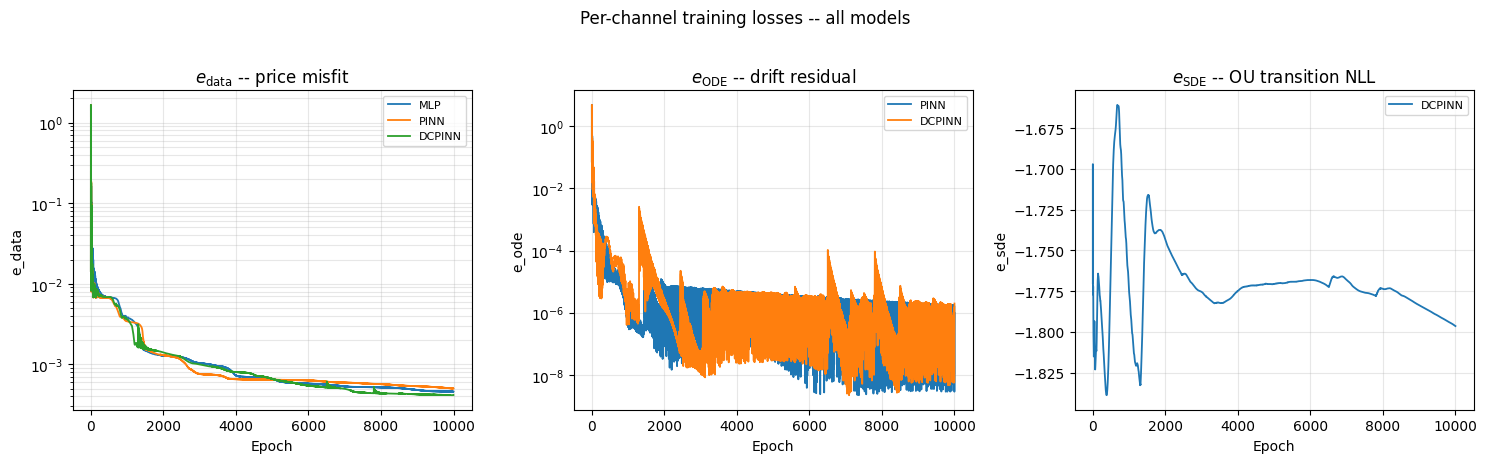

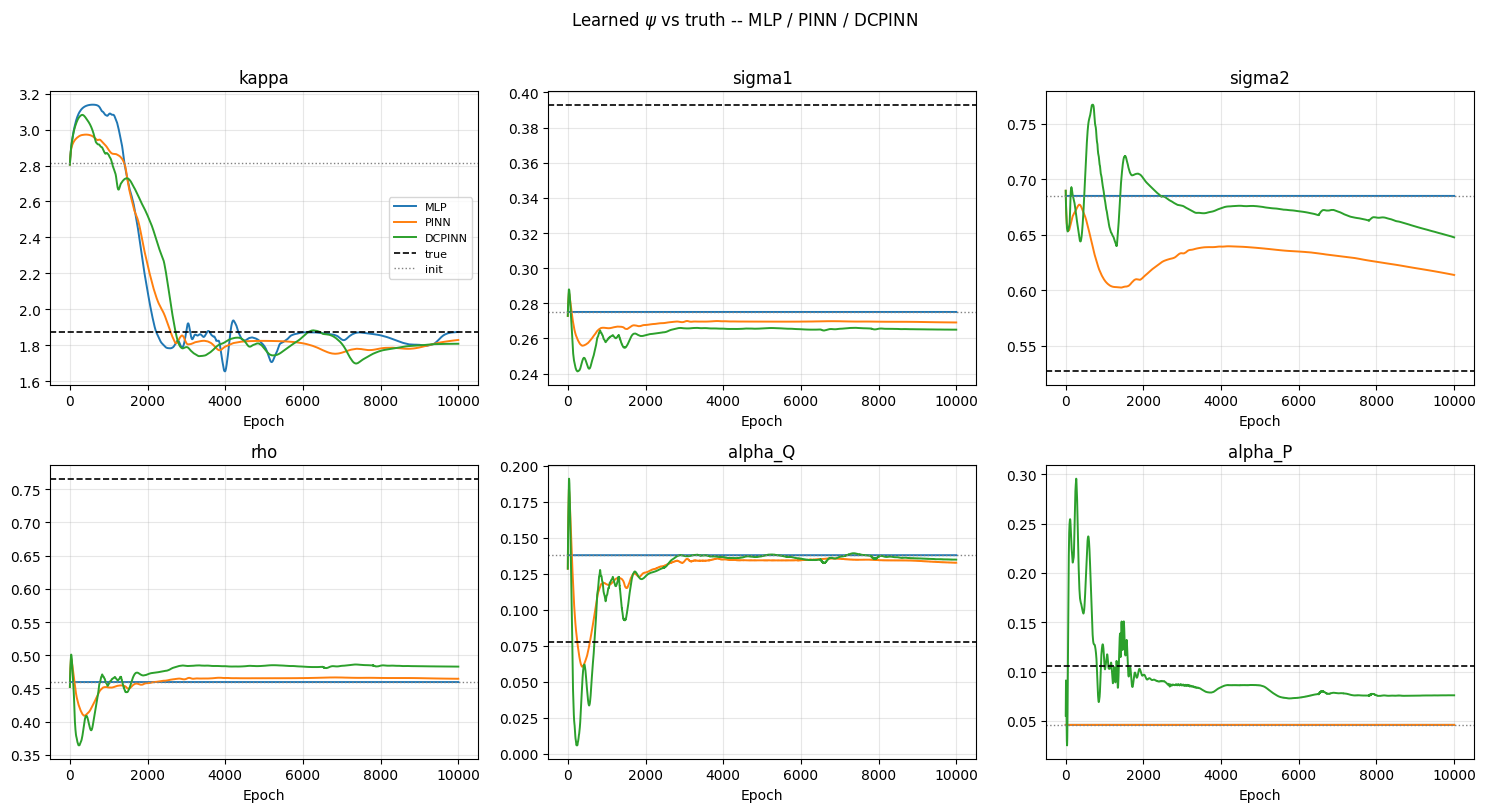

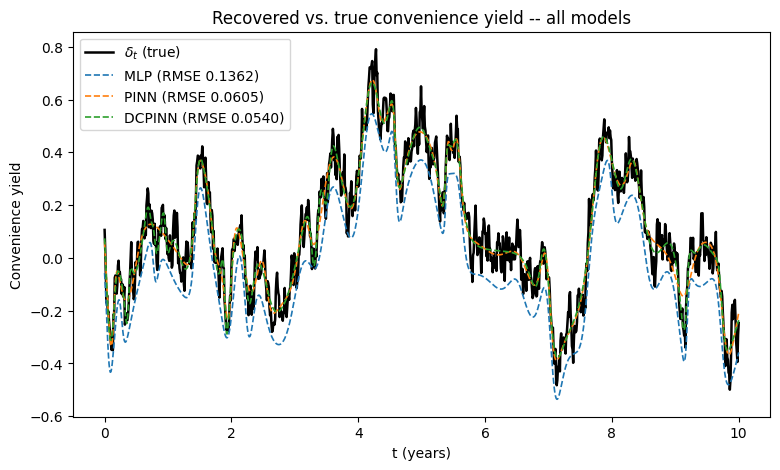

In [17]:
ORDER = ["kappa", "sigma1", "sigma2", "rho", "alpha_Q", "alpha_P"]


def _load_history(tag):
    # history entries are (epoch, loss, metric, psi_snapshot); psi added when psi
    # became a learned leaf.
    with open(f'../data/output/results/results_{tag}.pkl', 'rb') as f:
        return pickle.load(f)['history']


def plot_training_history_composite(configs, save_path=None):
    """Per-channel losses (one panel per channel), all models overlaid.

    Plots the UNWEIGHTED per-channel means stored in each run's history (the
    `metric` dict), not the WamOL-weighted total. A model is drawn in a channel
    only if it optimises that channel (init_l_ws).
    """
    channels = ['e_data', 'e_ode', 'e_sde']
    yscale = {'e_data': 'log', 'e_ode': 'log', 'e_sde': 'linear'}
    titles = {
        'e_data': r'$e_{\mathrm{data}}$ -- price misfit',
        'e_ode':  r'$e_{\mathrm{ODE}}$ -- drift residual',
        'e_sde':  r'$e_{\mathrm{SDE}}$ -- OU transition NLL',
    }
    runs = {}
    for config in configs:
        tag = run_tag(config)
        hist = _load_history(tag)
        epochs  = [h[0] for h in hist]
        metrics = [h[2] for h in hist]
        series  = {k: [float(m[k]) for m in metrics] for k in metrics[0]}
        runs[tag] = (epochs, series, set(init_l_ws[config.loss_str]))

    fig, axes = plt.subplots(1, len(channels), figsize=(15, 4.5))
    for ax, ch in zip(axes, channels):
        for tag, (epochs, series, trained) in runs.items():
            if ch in trained and ch in series:
                ax.plot(epochs, series[ch], lw=1.3, label=tag)
        ax.set_xlabel('Epoch'); ax.set_ylabel(ch); ax.set_yscale(yscale[ch])
        ax.set_title(titles[ch]); ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=8)
    fig.suptitle('Per-channel training losses -- all models', y=1.02)
    fig.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show(); plt.close()


def plot_psi_trajectories(configs, save_path=None):
    """Learned psi vs truth over training, one panel per parameter.

    A trajectory that sits on its (grey) init line is a parameter that model's
    channels do not identify.
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, p in zip(axes.ravel(), ORDER):
        for config in configs:
            tag = run_tag(config)
            hist = _load_history(tag)
            ax.plot([h[0] for h in hist], [h[3][p] for h in hist], lw=1.4, label=tag)
        ax.axhline(PSI_TRUE[p], color='black', ls='--', lw=1.2, label='true')
        ax.axhline(PSI_INIT[p], color='grey', ls=':', lw=1.0, label='init')
        ax.set_title(p); ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)
        if p == ORDER[0]:
            ax.legend(fontsize=8)
    fig.suptitle(r'Learned $\psi$ vs truth -- MLP / PINN / DCPINN', y=1.01)
    fig.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show(); plt.close()


def print_psi_table(configs):
    """Recovered psi vs true/init for each model (final epoch)."""
    tags = [run_tag(c) for c in configs]
    finals = {tag: _load_history(tag)[-1][3] for tag in tags}
    head = f"{'param':>8} | {'true':>9} | {'init':>9} | " + " | ".join(f"{t:>9}" for t in tags)
    print(head); print('-' * len(head))
    for p in ORDER:
        row = f"{p:>8} | {PSI_TRUE[p]:9.4f} | {PSI_INIT[p]:9.4f} | " + \
              " | ".join(f"{finals[t][p]:9.4f}" for t in tags)
        print(row)


def plot_delta_recovery_composite(fns_by_tag, t, delta_true, save_path=None):
    """Overlay recovered delta_hat_phi(t) for all models vs the true (eval-only) path."""
    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    ax.plot(t, delta_true, color='black', lw=1.8, label=r'$\delta_t$ (true)')
    for tag, fns in fns_by_tag.items():
        _, delta_hat_fn, _, _ = fns
        delta_hat = vmap(delta_hat_fn)(t)
        rmse = float(jnp.sqrt(jnp.mean((delta_hat - delta_true) ** 2)))
        ax.plot(t, delta_hat, lw=1.2, ls='--', label=f'{tag} (RMSE {rmse:.4f})')
    ax.set_xlabel('t (years)'); ax.set_ylabel('Convenience yield'); ax.legend()
    ax.set_title('Recovered vs. true convenience yield -- all models')
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show(); plt.close()


os.makedirs('../figures/pinn', exist_ok=True)

configs = [config_MLP, config_PINN, config_DCPINN]
fns_by_tag = {
    run_tag(config_MLP): fns_MLP,
    run_tag(config_PINN): fns_PINN,
    run_tag(config_DCPINN): fns_DCPINN,
}

print("Recovered psi vs true/init (final epoch):")
print_psi_table(configs)

plot_training_history_composite(configs, '../figures/pinn/training_history_composite.png')
plot_psi_trajectories(configs, '../figures/pinn/psi_trajectories.png')
plot_delta_recovery_composite(fns_by_tag, t_train, delta_true, '../figures/pinn/delta_recovery_composite.png')